 #      **Titanic Data Analysis Report**



## 1. Load Dataset

**We use the Titanic dataset from Kaggle**

In [84]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("train.csv")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
print(df.head())

   PassengerId  Survived  Pclass                                               Name     Sex   Age  SibSp  Parch            Ticket     Fare Cabin Embarked
0            1         0       3                            Braund, Mr. Owen Harris    male  22.0      1      0         A/5 21171   7.2500   NaN        S
1            2         1       1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1      0          PC 17599  71.2833   C85        C
2            3         1       3                             Heikkinen, Miss. Laina  female  26.0      0      0  STON/O2. 3101282   7.9250   NaN        S
3            4         1       1       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1      0            113803  53.1000  C123        S
4            5         0       3                           Allen, Mr. William Henry    male  35.0      0      0            373450   8.0500   NaN        S


## 2.Data Cleaning
**Handle Missing Values**


 **how many missing values are ther in it**

In [85]:
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


**finishing those missing values**

In [86]:
df['Age'] = df['Age'].fillna(df['Age'].mean())
df.columns = df.columns.str.strip()
df.drop('Cabin', axis=1, inplace=True, errors='ignore')
df = df.dropna(subset=['Embarked'])
print(df)

     PassengerId  Survived  Pclass                                               Name     Sex        Age  SibSp  Parch            Ticket     Fare Embarked
0              1         0       3                            Braund, Mr. Owen Harris    male  22.000000      1      0         A/5 21171   7.2500        S
1              2         1       1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.000000      1      0          PC 17599  71.2833        C
2              3         1       3                             Heikkinen, Miss. Laina  female  26.000000      0      0  STON/O2. 3101282   7.9250        S
3              4         1       1       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.000000      1      0            113803  53.1000        S
4              5         0       3                           Allen, Mr. William Henry    male  35.000000      0      0            373450   8.0500        S
..           ...       ...     ...                                    

## 3.Data Analysis
**1.Who survived more: Males or Females?**

In [93]:

print(df.groupby('Sex')['Survived'].sum())


Sex
female    231
male      109
Name: Survived, dtype: int64


Conclusion:
Females survived more than males.

**2.Did Passenger Class Affect Survival?**

In [94]:
print(df.groupby('Pclass')['Survived'].mean())

Pclass
1    0.626168
2    0.472826
3    0.242363
Name: Survived, dtype: float64


Conclusion:
1st class → Highest survival rate
3rd class → Lowest survival rate

**3.Survival Rate by Age Group**

In [95]:
# Create age groups
bins = [0, 12, 20, 40, 60, 100]
labels = ['Child', 'Teen', 'Adult', 'Mid-age', 'Senior']

df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)

print(df.groupby('AgeGroup')['Survived'].mean())

AgeGroup
Child      0.579710
Teen       0.381818
Adult      0.363636
Mid-age    0.390625
Senior     0.190476
Name: Survived, dtype: float64


Conclusion:
Children had better survival chances.

## 4. Data Visualization

1.**Survival by Gender**

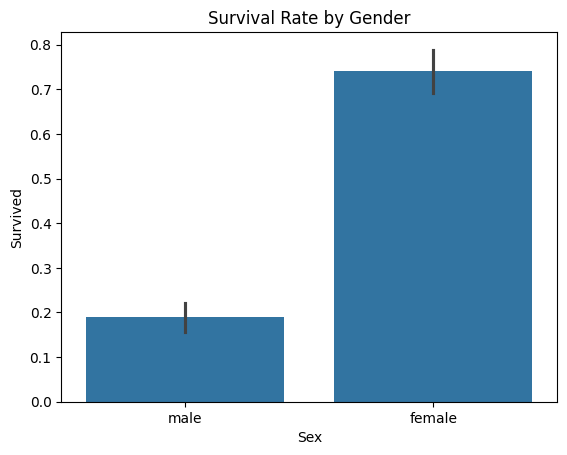

In [96]:
sns.barplot(x='Sex', y='Survived', data=df)
plt.title("Survival Rate by Gender")
plt.show()

**2.Survival by Passenger Class**

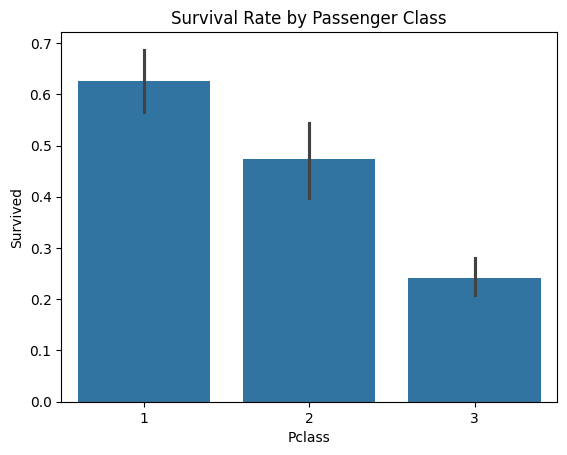

In [97]:
sns.barplot(x='Pclass', y='Survived', data=df)
plt.title("Survival Rate by Passenger Class")
plt.show()

**3.Age Distribution**

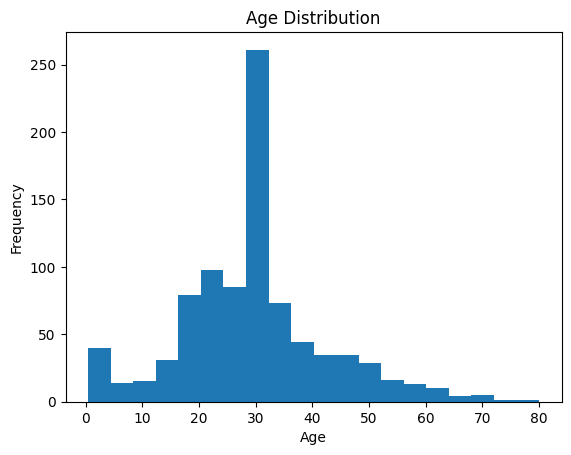

In [98]:
plt.hist(df['Age'], bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

##   **Conclusion**

- Females had a significantly higher survival rate compared to males.  
- Passenger class played an important role — passengers in 1st class had better chances of survival than those in 2nd and 3rd class.  
- Age also influenced survival — children had relatively higher survival rates than adults and elderly passengers.  
- Overall, gender, class, and age were key factors affecting survival on the Titanic.